# Cosine similarity (and relation to correlation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
import torch

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# generate some data

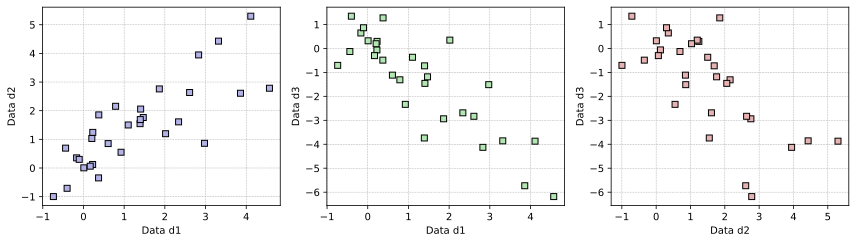

In [2]:
# sample size
N = 30

# data vectors
d1 = np.random.randn(N) + 1 # add an offset for Pearson vs. cosine-similarity
d2 = d1 + np.random.randn(N)
d3 = -d1 + np.random.randn(N)

# visualize
_, axs = plt.subplots(1, 3, figsize=(12,3.5))
axs[0].plot(d1, d2, 'ks', markerfacecolor=[.7,.7,.9])
axs[0].set(xlabel="Data d1", ylabel="Data d2")

axs[1].plot(d1, d3, 'ks', markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel="Data d1", ylabel="Data d3")

axs[2].plot(d2, d3, 'ks', markerfacecolor=[.9,.7,.7])
axs[2].set(xlabel="Data d2", ylabel="Data d3")

for a in axs: a.grid(linestyle='--', linewidth=.5)

plt.tight_layout()
plt.show()

# cosine similarity: manual calculation and sklearn

In [3]:
# cosine similarity manual
num = sum(d1*d2)
den = sum(d1*d1) * sum(d2**2)
cossim_manual = num / np.sqrt(den)

print(f'Manual calculation: Cosine similarity between d1 and d2 is {cossim_manual:.4f}')

Manual calculation: Cosine similarity between d1 and d2 is 0.8998


In [5]:
# check against sklearn
# cossim_sklearn = cosine_similarity(d1, d2)
cossim_sklearn = cosine_similarity(d1.reshape(1,-1), d2.reshape(1,-1))
print(f'Sci-kit learn: Cosine similarity between d1 and d2 is {cossim_sklearn[0][0]:.4f}')

Sci-kit learn: Cosine similarity between d1 and d2 is 0.8998


In [6]:
print(d1.reshape(1,-1).shape)
print(d1.shape)

(1, 30)
(30,)


# comparison with Pearson correlation coefficient

In [7]:
# mean-center
d1m = d1 - np.mean(d1)
d2m = d2 - np.mean(d2)

# manual calculation
num = sum(d1m*d2m)
den = sum(d1m*d1m) * sum(d2m*d2m)
corr_manual = num / np.sqrt(den)

# numpy
corr_np = np.corrcoef(d1, d2)[0, 1]

# cosine similarity using mean-centered data
cossimM_sklearn = cosine_similarity(d1m.reshape(1, -1), d2m.reshape(1, -1))

# print all the results
# print all the results
print(f'Manual calculation: Pearson correlation between d1 and d2 is {corr_manual:.7f}')
print(f'Numpy corrcoef():   Pearson correlation between d1 and d2 is {corr_np:.7f}')
print(f'Sci-kit learn:      Cosine similarity between d1m and d2m is {cossimM_sklearn[0][0]:.7f}')
print(f'Sci-kit learn:      Cosine similarity between d1 and d2 is   {cossim_sklearn[0][0]:.7f}')

Manual calculation: Pearson correlation between d1 and d2 is 0.8087999
Numpy corrcoef():   Pearson correlation between d1 and d2 is 0.8087999
Sci-kit learn:      Cosine similarity between d1m and d2m is 0.8087999
Sci-kit learn:      Cosine similarity between d1 and d2 is   0.8998260


# cosine similarity in PyTorch

In [8]:
torch.cosine_similarity(d1, d2)

TypeError: cosine_similarity(): argument 'x1' (position 1) must be Tensor, not numpy.ndarray

In [9]:
torch.cosine_similarity(torch.tensor(d1), torch.tensor(d2))

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [10]:
torch.cosine_similarity(torch.tensor(d1).view(1,-1), torch.tensor(d2).view(1,-1))

tensor([0.8998], dtype=torch.float64)

In [11]:
cossim_torch = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))

print(f'sklearn: Cosine similarity between d1 and d2 is {cossim_sklearn[0][0]:.7f}')
print(f'Torch:   Cosine similarity between d1 and d2 is {cossim_torch.item():.7f}')

sklearn: Cosine similarity between d1 and d2 is 0.8998260
Torch:   Cosine similarity between d1 and d2 is 0.8998260


# back to visualization

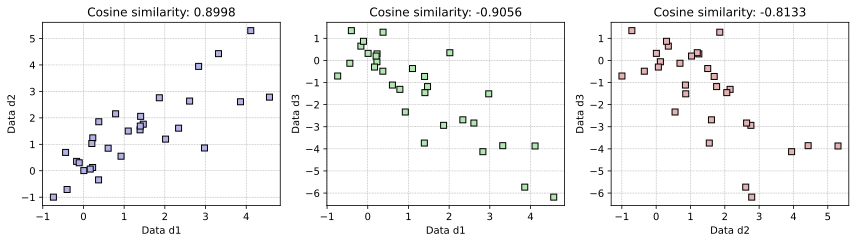

In [12]:
# cosine similarities
cs_d12 = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))
cs_d13 = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d3).view(1,-1))
cs_d23 = torch.cosine_similarity(torch.tensor(d2).view(1,-1),torch.tensor(d3).view(1,-1))

# visualize
_, axs = plt.subplots(1,3,figsize=(12,3.5))
axs[0].plot(d1, d2, 'ks', markerfacecolor=[.7,.7,.9])
axs[0].set(xlabel="Data d1", ylabel="Data d2", title=f"Cosine similarity: {cs_d12.item():.4f}")

axs[1].plot(d1, d3, 'ks', markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel="Data d1", ylabel="Data d3", title=f"Cosine similarity: {cs_d13.item():.4f}")

axs[2].plot(d2, d3, 'ks', markerfacecolor=[.9,.7,.7])
axs[2].set(xlabel="Data d2", ylabel="Data d3", title=f"Cosine similarity: {cs_d23.item():.4f}")

for a in axs: a.grid(linestyle='--', linewidth=.5)

plt.tight_layout()
plt.show()